# 02 · Analysis and figures

**Project question (fixed before looking at results):**
*During Nepal's 2020 COVID lockdown (from 24 March 2020), was Kathmandu's daily PM2.5 lower than in the same calendar weeks of 2017-2019, and by how much?*

**What this notebook does**
- **Part A: the main number and its 95% confidence interval.** One difference in µg/m³, with a range that says how sure we are.
- **Part B: robustness checks.** Does the answer survive other reasonable choices?
- **Part C: the figures** saved to `../figures/` and shown in the README.

**Rules for this notebook**
- Read only from `../data/processed/` (made by notebook 01). Never touch `data/raw/`.
- Relative paths only. Fixed random seed (42), so every run gives identical numbers.
- The question, the main number and the method were written down **before** this notebook was run, and weren't changed after seeing the result.

## How to read and run this notebook

Run notebook 01 first (it creates `data/processed/pm25_daily.csv`), then here choose **Kernel → Restart & Run All**. It takes about a minute.

- Each section starts with the **Approach** (what and why), then the code, then what was found.
- Lines marked **✅ Check** show the output you should see. If your numbers differ, something upstream is different (data file, package version, or a changed cell).
- **Answer** cells give the interpretation in plain words.

## The map: from the cleaned data to one number

```
pm25_daily.csv  (2,944 rows = 1,472 days × 2 stations)        <- made by notebook 01
      |
      |  keep: Phora Durbar · valid days (>= 18 h) · 24 Mar - 21 Jul of each year
      v
win  (407 rows = one valid day in a lockdown window)
      |
      |  group by year, take the mean of the daily means
      v
yearly  (4 rows: 2017, 2018, 2019, 2020)
      |
      |  baseline = average of 2017, 2018, 2019        main number = 2020 - baseline
      v
ONE NUMBER (µg/m³)  +  bootstrap: redo the whole thing 2,000 times on resampled days
      |
      v
95% confidence interval  ->  the answer sentence
```

Ask yourself after every cell: **what is one row now, and how many rows are there?**

## 0 · Setup

Besides the imports, this cell holds every **choice** of the analysis as a named constant at the top. A reader sees all the decisions in one place, and a robustness check later only has to change one line.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED = Path("../data/processed")      # relative path: works on any computer

# The analysis choices, all in one place (decided BEFORE seeing the result)
WINDOW_START, WINDOW_END = "03-24", "07-21"   # lockdown 24 Mar - 21 Jul 2020 (inclusive), month-day
LOCKDOWN_YEAR = 2020
BASELINE_YEARS = [2017, 2018, 2019]
YEARS = BASELINE_YEARS + [LOCKDOWN_YEAR]
MAIN_STATION = "phora_durbar"                 # more valid 2020 days than Embassy (see section 2)
SEED = 42                                     # fixed seed = identical numbers on every run
N_BOOT = 2000                                 # number of bootstrap resamples

# Colour-blind-safe colours (Okabe-Ito): grey for the "before" years, orange for 2020
COLORS = {2017: "#BBBBBB", 2018: "#999999", 2019: "#666666", 2020: "#E69F00"}

print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.6 | numpy 2.5.3


✅ **Check:** prints your pandas and numpy versions (pandas 3.0.x, numpy 2.x).

## 1 · The lockdown dates (checked and cited)

Notebook 01 used 24 Mar – 21 Jul as a *provisional* window. Two newspapers confirm it:

| Date | Event |
|---|---|
| 24 Mar 2020 | Nationwide lockdown starts |
| 11 Jun 2020 | Lockdown eased (some shops reopen, odd-even rule for private vehicles) |
| 21 Jul 2020 | Cabinet lifts the lockdown, effective midnight (some restrictions remain) |

**Sources:** Tika R. Pradhan, *"Government decides to lift the four-month-long coronavirus lockdown but with conditions"*, The Kathmandu Post, 21 July 2020 ([link](https://kathmandupost.com/national/2020/07/21/government-decides-to-lift-the-four-month-long-coronavirus-lockdown-but-with-conditions)); *"Nepal ends COVID-19 lockdown"*, Nepali Times, 21 July 2020 ([link](https://nepalitimes.com/nepal-ends-covid-19-lockdown)).

**Window used:** 24 March to 21 July, both days included = **120 days**, in every year. Because the window starts after February, a leap year (2020) doesn't change its length.

**Same calendar weeks, every year.** PM2.5 in Kathmandu falls steeply from March (dry, dusty, forest fires) to July (monsoon rain washes the air). Comparing the *same dates* across years removes most of that seasonal effect, so what's left is mostly the difference between years.

## 2 · Load the cleaned daily table

**Approach:** notebook 01 already did the hard work. One row of `pm25_daily.csv` = **one station × one Nepal calendar day**. Its columns:

| Column | Meaning |
|---|---|
| `station` | `embassy` or `phora_durbar` |
| `date` | Nepal calendar day (midnight to midnight, UTC+05:45) |
| `n_hours` | how many valid hourly readings that day had (0-24) |
| `pm25_mean` | mean of that day's hourly PM2.5, µg/m³ **← the main measure** |
| `pm25_median` | median of that day's hourly PM2.5 (robustness check, Part B) |
| `pm25_mean_no_suspect` | mean without the `is_suspect` hours (robustness check, Part B) |
| `valid_day` | `True` if `n_hours >= 18` (the rule from notebook 01) |

Days with zero readings are **still in the table** (with `n_hours = 0` and empty means), so we can count gaps. Always check the file looks the way the previous notebook left it.

In [2]:
daily = pd.read_csv(PROCESSED / "pm25_daily.csv", parse_dates=["date"])

print(daily.shape)                                   # expect (2944, 7)
print(daily.dtypes, "\n")
# Sanity checks: one row per station per day, and the valid-day rule matches n_hours
assert not daily.duplicated(subset=["station", "date"]).any(), "duplicate station-days"
assert (daily["valid_day"] == (daily["n_hours"] >= 18)).all(), "valid_day doesn't match the 18 h rule"
print("Valid days per station:")
print(daily.groupby("station")["valid_day"].sum())
daily.head()

(2944, 7)
station                            str
date                    datetime64[us]
n_hours                          int64
pm25_mean                      float64
pm25_median                    float64
pm25_mean_no_suspect           float64
valid_day                         bool
dtype: object 

Valid days per station:
station
embassy         1118
phora_durbar    1202
Name: valid_day, dtype: int64


,station,date,n_hours,pm25_mean,pm25_median,pm25_mean_no_suspect,valid_day
0,embassy,2017-03-03,19,128.615789,95.00,128.615789,True
1,embassy,2017-03-04,6,134.516667,130.35,134.516667,False
2,embassy,2017-03-05,0,NaN,NaN,NaN,False
3,embassy,2017-03-06,0,NaN,NaN,NaN,False
4,embassy,2017-03-07,0,NaN,NaN,NaN,False


✅ **Check:** shape `(2944, 7)`; `date` is `datetime64`, `valid_day` is `bool`; valid days: embassy **1,118**, phora_durbar **1,202**.

## 3 · Choose the station: count valid days inside each year's window

**Approach:** the decision log from notebook 01 *recommended* Phora Durbar as the main station. Confirm it with a count. The station with more valid days in the **2020** window gives a better estimate of the very number we're testing.

We also add two helper columns that every later step uses:
- `year`: 2017, 2018, ...
- `md`: month-day as text, e.g. `"04-15"`. Text in `"MM-DD"` form sorts like the calendar, so `"03-24" <= md <= "07-21"` picks the window in **every** year with one line.

**Why not average the two stations?** They agree on *when* air is bad (correlation 0.92) but Phora Durbar reads about 8 µg/m³ higher. If one station is offline on some days, an average silently switches between levels. Use one station for the main number and the other as a check (Part B).

In [3]:
daily["year"] = daily["date"].dt.year
daily["md"] = daily["date"].dt.strftime("%m-%d")          # "03-24", "07-21", ...
in_window = daily["md"].between(WINDOW_START, WINDOW_END)  # True for 24 Mar - 21 Jul (inclusive)

coverage = (daily[in_window & daily["year"].isin(YEARS)]
            .pivot_table(index="year", columns="station", values="valid_day", aggfunc="sum"))
coverage["days_in_window"] = daily[in_window & daily["year"].isin(YEARS)].groupby("year").size() // 2
coverage

station,embassy,phora_durbar,days_in_window
year,,,
2017,85,89,120
2018,95,93,120
2019,113,113,120
2020,84,112,120


✅ **Check:** 120 days in every window. Valid days (embassy / phora_durbar): 2017 **85 / 89**, 2018 **95 / 93**, 2019 **113 / 113**, 2020 **84 / 112**.

> **Answer:** **Phora Durbar** has **112 of 120** valid days in the 2020 window; Embassy has only **84**. The 2020 mean is the very number being tested, so the station with more 2020 days gives a more precise estimate and is less exposed to gaps (Part B shows Embassy is missing about a third of its May-June 2020 days).
>
> Averaging the two stations day by day would mix two different levels: Phora Durbar reads about 8 µg/m³ higher. On days when one monitor is offline, the "average" would jump up or down for reasons that have nothing to do with the air. So Phora Durbar is the main station and Embassy is a robustness check.

## 4 · Build `win`: the days that answer the question

**Approach:** three filters, combined with `&` (and):
1. the main station,
2. a **valid** day (≥ 18 of 24 hours),
3. inside the window, in one of the four years.

Also add `day`: days since 24 March of that year (0 = 24 Mar, 119 = 21 Jul). It lets us line up the four years on one x-axis.

**Why drop invalid days instead of filling them?** A day with only 6 hours might be 6 night hours (cleaner air) or 6 rush hours (dirtier). Its mean isn't comparable to a full day. Filling missing days (interpolation) would invent data and make the confidence interval look narrower than it should be.

In [4]:
keep = (in_window
        & daily["valid_day"]
        & (daily["station"] == MAIN_STATION)
        & daily["year"].isin(YEARS))
win = daily[keep].copy()

window_start = pd.to_datetime(win["year"].astype(str) + "-" + WINDOW_START)
win["day"] = (win["date"] - window_start).dt.days       # 0 = 24 Mar ... 119 = 21 Jul

print(win.shape)
print(win.groupby("year").size())
assert win["day"].between(0, 119).all()
win[["date", "year", "day", "n_hours", "pm25_mean"]].head()

(407, 10)
year
2017     89
2018     93
2019    113
2020    112
dtype: int64


,date,year,day,n_hours,pm25_mean
1493,2017-03-24,2017,0,20,78.250000
1514,2017-04-14,2017,21,24,134.916667
1515,2017-04-15,2017,22,24,62.625000
1516,2017-04-16,2017,23,24,67.958333
1517,2017-04-17,2017,24,24,76.083333


✅ **Check:** `win` has **407 rows** (89 + 93 + 113 + 112). One row = one valid Phora Durbar day inside a lockdown window.

## 5 · Look before you summarise: the season and the gaps

**Approach:** before reducing 407 days to one number, look at two things:
- **Which parts of the window are missing in each year?** If a year is missing mostly March days (the dirty part), its average looks too clean.
- **How does PM2.5 move through the window?** Mean per month, per year.

This is where you protect yourself from a misleading average.

In [5]:
month_names = {3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul"}
win["month"] = win["date"].dt.month.map(month_names)
order = list(month_names.values())

days_per_month = pd.crosstab(win["year"], win["month"])[order]
mean_per_month = win.pivot_table(index="year", columns="month", values="pm25_mean", aggfunc="mean")[order].round(1)

print("Valid days per month (Mar has only 8 window days: 24-31 Mar; Jul has 21):")
display(days_per_month)
print("Mean daily PM2.5 per month (µg/m³):")
display(mean_per_month)

Valid days per month (Mar has only 8 window days: 24-31 Mar; Jul has 21):


month,Mar,Apr,May,Jun,Jul
year,,,,,
2017,1,13,27,28,20
2018,7,26,17,22,21
2019,7,29,29,30,18
2020,8,29,26,30,19


Mean daily PM2.5 per month (µg/m³):


month,Mar,Apr,May,Jun,Jul
year,,,,,
2017,78.2,77.6,52.7,33.9,20.1
2018,98.8,70.0,44.5,32.3,15.9
2019,91.1,59.0,67.0,33.6,19.2
2020,36.8,47.4,25.3,13.3,12.7


✅ **Check:** 2017 has only **1** valid March day and **13** in April. In every month, 2020 is the lowest row (e.g. Apr: 2017 77.6, 2018 70.0, 2019 59.0, **2020 47.4**).

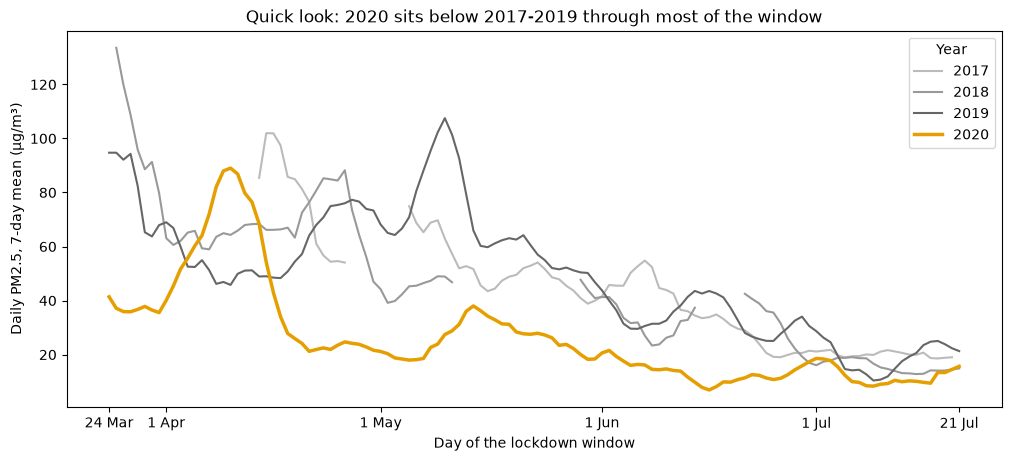

In [6]:
# A quick-look chart (not a final figure): 7-day rolling mean, four years on one axis.
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
for y in YEARS:
    s = (win[win["year"] == y].set_index("day")["pm25_mean"]
         .reindex(range(120)))                                     # missing days -> NaN (a visible gap)
    smooth = s.rolling(7, center=True, min_periods=4).mean()       # needs >= 4 real days in the 7
    ax.plot(smooth.index, smooth, color=COLORS[y],
            lw=2.5 if y == LOCKDOWN_YEAR else 1.5, label=str(y))
ticks = [0, 8, 38, 69, 99, 119]
ax.set_xticks(ticks, ["24 Mar", "1 Apr", "1 May", "1 Jun", "1 Jul", "21 Jul"])
ax.set_ylabel("Daily PM2.5, 7-day mean (µg/m³)")
ax.set_xlabel("Day of the lockdown window")
ax.set_title("Quick look: 2020 sits below 2017-2019 through most of the window")
ax.legend(title="Year")
plt.show()

**What to look for:** all four years fall from spring to monsoon (the season), and the orange 2020 line sits below the grey lines for most of the window (the lockdown year). Gaps in a line are missing days. Notice where 2017's line starts.

> **Answer:** **2017.** It has only **1** valid March day and **13** April days (the monitor was off 25 Mar - 13 Apr 2017), so its window average leans on the cleaner May-July days. Its mean (43.4 µg/m³) is therefore **too low**, which makes the baseline too low and the 2020 drop look **smaller** than it really was. The bias works **against** our finding, not for it. Part B checks it two ways: a 2018-2019 baseline, and comparing only calendar days present in all four years.
>
> The chart also shows a 2020 bump around 5-14 April (up to 123 µg/m³ on 11 April). Nepali Times (1 Sep 2020) reports a "sharp deterioration in air quality mid April ... in Kathmandu Valley despite vehicles being off the roads", caused by wildfires in surrounding districts. That's a confounder we keep in the data and discuss in the limitations.

## 6 · The main number

**Approach:** exactly as written down before the analysis:

1. **Per year:** the mean of the daily means → 4 numbers.
2. **Baseline:** the average of the 2017, 2018 and 2019 means, each year counting **equally**.
3. **Main number = 2020 mean − baseline** (negative = cleaner in 2020).
4. Also as a **percent change** = difference ÷ baseline × 100, which is easier for non-experts.

**Why average the three yearly means, rather than pool all 295 baseline days?** Pooling gives each *day* equal weight, so 2019 (113 days) counts more than 2017 (89 days) only because its monitor ran more often. The question says "the same weeks of 2017-2019", so each *year* should count the same. Here both give almost the same answer (shown below), but the per-year version is the one we defined.

In [7]:
yearly = win.groupby("year")["pm25_mean"].agg(n_days="size", mean="mean", median="median", sd="std")

baseline = yearly.loc[BASELINE_YEARS, "mean"].mean()          # equal weight per year
lockdown_mean = yearly.loc[LOCKDOWN_YEAR, "mean"]
difference = lockdown_mean - baseline
pct_change = difference / baseline * 100

display(yearly.round(2))
print(f"Baseline (mean of 2017-2019 yearly means): {baseline:.2f} µg/m³")
print(f"2020 lockdown weeks:                         {lockdown_mean:.2f} µg/m³")
print(f"Difference (2020 - baseline):               {difference:+.2f} µg/m³  ({pct_change:+.1f}%)")

pooled = win.loc[win["year"].isin(BASELINE_YEARS), "pm25_mean"].mean()
print(f"\nFor comparison, pooled-days baseline: {pooled:.2f} µg/m³ -> difference {lockdown_mean - pooled:+.2f}")

,n_days,mean,median,sd
year,,,,
2017,89,43.37,39.42,26.13
2018,93,46.36,42.20,30.11
2019,113,49.94,45.71,27.13
2020,112,26.49,20.83,21.66


Baseline (mean of 2017-2019 yearly means): 46.56 µg/m³
2020 lockdown weeks:                         26.49 µg/m³
Difference (2020 - baseline):               -20.07 µg/m³  (-43.1%)

For comparison, pooled-days baseline: 46.83 µg/m³ -> difference -20.34


✅ **Check:** yearly means 2017 **43.37**, 2018 **46.36**, 2019 **49.94**, 2020 **26.49**; baseline **46.56**; difference **−20.07 µg/m³ (−43.1%)**.

**Sanity check by hand** (always do one): (43.37 + 46.36 + 49.94) / 3 = 139.67 / 3 = 46.56. Then 26.49 − 46.56 = −20.07. ✔
Does it make sense in real units? A drop from about 47 to 26 µg/m³ is large. For scale, the WHO 24-hour guideline is 15 µg/m³, so even lockdown air was above it on average.

> **Answer:** In the 2020 lockdown weeks, mean daily PM2.5 at Phora Durbar was **26.49 µg/m³**, against **46.56 µg/m³** in the same weeks of 2017-2019: a difference of **−20.07 µg/m³ (−43.1%)**.
>
> A bare number isn't enough because it comes from the particular days we happened to observe. With other days (or another year's weather), it would be somewhat different. Without a range we can't tell whether −20 is a clear drop or something that could easily be 0, so it needs a confidence interval.

## 7 · Why we need a confidence interval

The −20.07 is computed from **the days we happen to have**. If the monitor had been offline on different days, or the weather in 2019 had been a bit different, we'd get a slightly different number. A **95% confidence interval** answers: *how much could this number wobble just from which days we happened to observe?*

**Interpretation to remember:** if we repeated the whole study many times on new samples, about 95% of intervals made this way would contain the true difference. In plain words: "we're fairly confident the true difference is somewhere in this range". If the whole interval is below zero, the drop is very unlikely to be a fluke of which days we sampled.

### The bootstrap idea (no formulas)
We don't have other years of 2020 to look at. So we **pretend our sample is the population**, and draw new samples from it:

1. From the 112 days of 2020, draw 112 days **with replacement** (some days twice, some not at all).
2. Do the same for 2017 (89 draws), 2018 (93) and 2019 (113).
3. Recompute the four yearly means, the baseline and the difference → one "bootstrap difference".
4. Repeat 2,000 times → 2,000 differences. Their spread shows how much the number wobbles.
5. The middle 95% (2.5th to 97.5th percentile) is the 95% CI.

### Three choices, and why
| Choice | What we do | Why |
|---|---|---|
| **Unit = days, not hours** | resample daily means | The 24 hours of a day are strongly linked (same weather, same traffic). 112 days hold 2,625 hourly readings, but those hours aren't 2,625 independent facts. Resampling hours would pretend they are and give a CI that's far too narrow (falsely confident). |
| **Stratified by year** | resample each year separately, keeping its own number of days | The main number is built *per year* (equal weight). Each resample must have the same structure: 112 days of 2020, 89 of 2017, ... If we resampled all 407 days together, a resample could contain 130 days of 2019 and 70 of 2017, which is not our design. |
| **Fixed seed (42)** | `np.random.default_rng(SEED)` | Random draws, but the same random draws every run, so a stranger gets your exact CI. |

### First, see resampling with a tiny example

Five "days" with values 10, 20, 30, 40, 50. Watch what `rng.choice(..., replace=True)` does.

In [8]:
rng = np.random.default_rng(SEED)
toy = np.array([10, 20, 30, 40, 50])
print("original:", toy, "mean", toy.mean())
for i in range(4):
    r = rng.choice(toy, size=len(toy), replace=True)
    print(f"resample {i+1}:", r, "mean", r.mean())

original: [10 20 30 40 50] mean 30.0
resample 1: [10 40 40 30 30] mean 30.0
resample 2: [50 10 40 20 10] mean 26.0
resample 3: [30 50 40 40 40] mean 40.0
resample 4: [40 30 10 50 30] mean 32.0


✅ **Check:** each resample has 5 values, some repeated, some missing, and its mean wobbles around 30. That wobble is what the bootstrap measures.

## 8 · The bootstrap CI for the main number

**Approach:**
- `values_by_year`: a dictionary `{year: array of that year's daily means}`. Pulling the numbers out of pandas once makes the loop fast (2,000 × 4 resamples).
- One `rng`, created once with the seed, then used for every draw in a fixed order (2017, 2018, 2019, 2020). Same order + same seed = same result.
- Store each bootstrap difference (and percent) in a NumPy array, then take percentiles.

In [9]:
values_by_year = {y: win.loc[win["year"] == y, "pm25_mean"].to_numpy() for y in YEARS}

rng = np.random.default_rng(SEED)
boot_diff = np.empty(N_BOOT)
boot_pct = np.empty(N_BOOT)

for i in range(N_BOOT):
    means = {}
    for y in YEARS:                                    # stratified: each year resampled on its own
        v = values_by_year[y]
        means[y] = rng.choice(v, size=len(v), replace=True).mean()
    base = np.mean([means[y] for y in BASELINE_YEARS])
    boot_diff[i] = means[LOCKDOWN_YEAR] - base
    boot_pct[i] = boot_diff[i] / base * 100

ci_low, ci_high = np.percentile(boot_diff, [2.5, 97.5])
pct_low, pct_high = np.percentile(boot_pct, [2.5, 97.5])

print(f"Difference: {difference:+.1f} µg/m³   95% CI {ci_low:+.1f} to {ci_high:+.1f}")
print(f"Percent:    {pct_change:+.1f}%        95% CI {pct_low:+.1f}% to {pct_high:+.1f}%")
print(f"Bootstrap standard error: {boot_diff.std(ddof=1):.2f} µg/m³")
print(f"Share of bootstrap differences >= 0: {(boot_diff >= 0).mean():.4f}")

Difference: -20.1 µg/m³   95% CI -25.1 to -15.2
Percent:    -43.1%        95% CI -51.9% to -33.4%
Bootstrap standard error: 2.62 µg/m³
Share of bootstrap differences >= 0: 0.0000


✅ **Check:** difference **−20.1 µg/m³, 95% CI −25.1 to −15.2**; percent **−43.1%, 95% CI −51.9% to −33.4%**; standard error ≈ **2.6**; share ≥ 0 = **0.0000** (none of the 2,000 resamples showed 2020 as dirtier or equal).

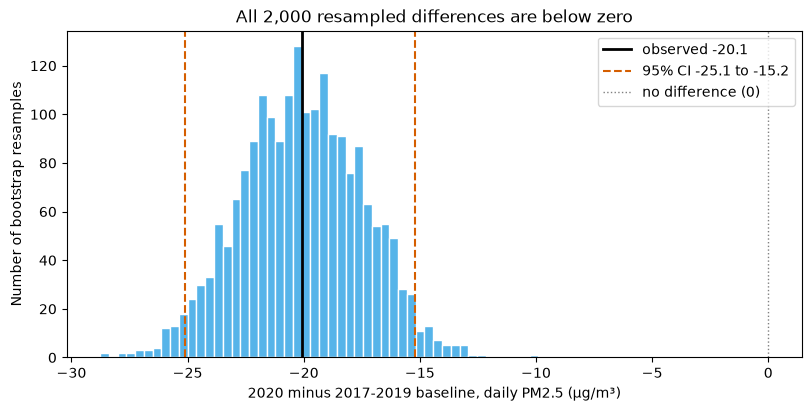

In [10]:
# Look at the 2,000 bootstrap differences: the CI is the middle 95% of this histogram.
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.hist(boot_diff, bins=50, color="#56B4E9", edgecolor="white")
ax.axvline(difference, color="black", lw=2, label=f"observed {difference:.1f}")
ax.axvline(ci_low, color="#D55E00", ls="--", label=f"95% CI {ci_low:.1f} to {ci_high:.1f}")
ax.axvline(ci_high, color="#D55E00", ls="--")
ax.axvline(0, color="grey", lw=1, ls=":", label="no difference (0)")
ax.set_xlabel("2020 minus 2017-2019 baseline, daily PM2.5 (µg/m³)")
ax.set_ylabel("Number of bootstrap resamples")
ax.set_title("All 2,000 resampled differences are below zero")
ax.legend()
plt.show()

**Reading the histogram:** it's roughly bell-shaped and centred on the observed −20. The dashed lines cut off 2.5% in each tail. The dotted line at 0 ("no change") is far to the right of every bar.

> **Answer:** PM2.5 was **20.1 µg/m³ lower** in the 2020 lockdown weeks (95% CI **15.2 to 25.1** lower), a **43% drop** (95% CI 33% to 52%).
>
> For a non-expert: "if we had measured on a different set of days, the drop would still very likely be somewhere between 15 and 25 µg/m³". None of the 2,000 resamples came close to zero.
>
> We resample **days**, not hours, because the 24 hours of a day share the same weather and traffic: they aren't 2,625 independent facts, and resampling them would make the interval falsely narrow. We resample **within each year** because the estimate is built from four yearly means with equal weight, and every resample must keep that structure (112 days of 2020, 89 of 2017, ...).

## 9 · A CI for each year's mean (needed for Figure 1 later)

**Approach:** the same bootstrap, one year at a time. Figure 1 (Part C) will show the four yearly means with these error bars, so the reader sees the gap *and* the uncertainty.

A new `rng` with the same seed makes this cell give the same output whether or not you ran section 8 first.

In [11]:
rng = np.random.default_rng(SEED)
rows = []
for y in YEARS:
    v = values_by_year[y]
    boot_means = [rng.choice(v, size=len(v), replace=True).mean() for _ in range(N_BOOT)]
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    rows.append({"year": y, "n_days": len(v), "mean": v.mean(), "ci_low": lo, "ci_high": hi})
year_ci = pd.DataFrame(rows).set_index("year").round(1)
year_ci

,n_days,mean,ci_low,ci_high
year,,,,
2017,89,43.4,38.2,49.0
2018,93,46.4,40.6,52.3
2019,113,49.9,45.2,55.1
2020,112,26.5,22.7,30.8


✅ **Check:** 2017 43.4 (38.2–49.0), 2018 46.4 (40.6–52.3), 2019 49.9 (45.2–55.1), **2020 26.5 (22.7–30.8)**. The 2020 interval doesn't overlap any baseline year's.

## 10 · Optional: a permutation test (a p-value)

**The question it answers:** *if the year labels meant nothing* (2020 no different from the other years), how often would a random shuffle of labels produce a difference as big as −20?

**Approach:**
1. Keep all 407 daily values. **Shuffle the year labels** (each year keeps its number of days).
2. Recompute the difference with the shuffled labels. Repeat 5,000 times. This is the "no real difference" world.
3. p-value = share of shuffles at least as extreme as the real −20 (both directions: `abs`).

We add 1 to the top and bottom: `(count + 1) / (n + 1)`. This counts the real labelling as one of the possible shuffles, so p can never be exactly 0. With 5,000 shuffles the smallest possible p is 1/5,001 ≈ 0.0002.

**CI vs p-value:** the CI tells you **how big** the effect is. The p-value only tells you whether "no effect" is plausible. Report the CI as the main result; the p-value is a supporting extra.

In [12]:
rng = np.random.default_rng(SEED)
values = win["pm25_mean"].to_numpy()
labels = win["year"].to_numpy()

def diff_from_labels(values, labels):
    means = {y: values[labels == y].mean() for y in YEARS}
    return means[LOCKDOWN_YEAR] - np.mean([means[y] for y in BASELINE_YEARS])

observed = diff_from_labels(values, labels)
N_PERM = 5000
null = np.array([diff_from_labels(values, rng.permutation(labels)) for _ in range(N_PERM)])
p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (N_PERM + 1)

print(f"Observed difference: {observed:.2f}")
print(f"Shuffled differences range from {null.min():.1f} to {null.max():.1f}")
print(f"p-value: {p_value:.4f}  (smallest possible with {N_PERM} shuffles: {1/(N_PERM+1):.4f})")

Observed difference: -20.07
Shuffled differences range from -11.3 to 10.9
p-value: 0.0002  (smallest possible with 5000 shuffles: 0.0002)


✅ **Check:** observed **−20.07**; shuffled differences only reach about **−11 to +11**; p = **0.0002** (the smallest possible). Report it as **p < 0.001**.

## 11 · Honesty check: are the days really independent?

The day bootstrap assumes each day is a separate, independent draw. But polluted air often **lingers for several days** (the same weather system, the same fire season). If today is dirty, tomorrow probably is too. That's called **autocorrelation**. With strongly linked days, 112 days carry less information than 112 independent days, and the day-bootstrap CI comes out **too narrow**.

**Approach:**
1. Measure the lag-1 autocorrelation: the correlation of each day with the next day, inside each year's window.
2. Re-run the bootstrap resampling **whole weeks** (blocks of 7 consecutive days) instead of single days. Keeping each week together keeps the day-to-day linkage inside the resample, so the CI reflects it. This is a **block bootstrap**.

This doesn't replace the main CI (we defined that before the analysis). It tells us how much to trust its width, and it goes in the README.

In [13]:
# 1) Lag-1 autocorrelation inside each window (consecutive calendar days; gaps stay as NaN)
for y in YEARS:
    s = win[win["year"] == y].set_index("day")["pm25_mean"].reindex(range(120))
    print(y, "lag-1 autocorrelation:", round(s.autocorr(lag=1), 2))

2017 lag-1 autocorrelation: 0.71
2018 lag-1 autocorrelation: 0.86
2019 lag-1 autocorrelation: 0.83
2020 lag-1 autocorrelation: 0.9


✅ **Check:** about **0.71 to 0.90**. Today's PM2.5 is a strong predictor of tomorrow's, so the days aren't independent.

In [14]:
# 2) Block bootstrap: resample weeks (7-day blocks from 24 Mar), stratified by year
win["week"] = win["day"] // 7                         # 0..17 (week 17 is just 21 Jul)
blocks_by_year = {y: [g["pm25_mean"].to_numpy() for _, g in win[win["year"] == y].groupby("week")]
                  for y in YEARS}

rng = np.random.default_rng(SEED)
block_diff = np.empty(N_BOOT)
for i in range(N_BOOT):
    means = {}
    for y in YEARS:
        blocks = blocks_by_year[y]
        picked = rng.integers(0, len(blocks), size=len(blocks))     # draw week numbers with replacement
        means[y] = np.concatenate([blocks[j] for j in picked]).mean()
    block_diff[i] = means[LOCKDOWN_YEAR] - np.mean([means[y] for y in BASELINE_YEARS])

b_low, b_high = np.percentile(block_diff, [2.5, 97.5])
print(f"Day bootstrap  (main):  95% CI {ci_low:+.1f} to {ci_high:+.1f}   (SE {boot_diff.std(ddof=1):.1f})")
print(f"Week bootstrap (check): 95% CI {b_low:+.1f} to {b_high:+.1f}   (SE {block_diff.std(ddof=1):.1f})")

Day bootstrap  (main):  95% CI -25.1 to -15.2   (SE 2.6)
Week bootstrap (check): 95% CI -31.7 to -7.2   (SE 6.2)


✅ **Check:** week bootstrap 95% CI ≈ **−31.7 to −7.2** (SE ≈ 6.2), more than twice as wide as the day bootstrap (SE ≈ 2.6). **It still doesn't include 0.**

**What this means:** the *direction* of the answer (cleaner air in 2020) is solid either way. The *exact size* is less certain than the day bootstrap suggests: the honest range is closer to "roughly 7 to 32 µg/m³ lower". Say this in the README's robustness and limitations sections. That kind of honesty is what reviewers look for.

> **Answer:** **Autocorrelation** means a value is linked to the values just before it. Here, today's PM2.5 strongly predicts tomorrow's (lag-1 correlation 0.71-0.90), because weather systems and smoke last several days. The day bootstrap treats every day as an independent draw, so it counts linked days as separate evidence, and the interval comes out too narrow.
>
> Resampling whole **weeks** keeps neighbouring days together. The CI widens from −25.1 to −15.2 to **−31.7 to −7.2** µg/m³, but it **still excludes zero**, so the conclusion (lower PM2.5 in 2020) doesn't change; only the precision of the size does. The README reports the pre-planned day-bootstrap CI as the headline and the week-block CI right next to it.

## 12 · The answer (Part A)

In [15]:
summary = pd.DataFrame({
    "estimate": [difference, pct_change],
    "ci_low (day bootstrap)": [ci_low, pct_low],
    "ci_high (day bootstrap)": [ci_high, pct_high],
}, index=["difference (µg/m³)", "percent change (%)"]).round(1)
display(summary)

print(f"During the 2020 lockdown weeks (24 Mar - 21 Jul), mean daily PM2.5 at Phora Durbar was "
      f"{lockdown_mean:.1f} µg/m³ versus {baseline:.1f} µg/m³ in the same weeks of 2017-2019: "
      f"{abs(difference):.1f} µg/m³ lower (95% CI {abs(ci_high):.1f} to {abs(ci_low):.1f}), "
      f"a {abs(pct_change):.0f}% drop. Resampling whole weeks widens the CI to "
      f"{abs(b_high):.1f}-{abs(b_low):.1f} µg/m³, still clearly below zero.")

,estimate,ci_low (day bootstrap),ci_high (day bootstrap)
difference (µg/m³),-20.1,-25.1,-15.2
percent change (%),-43.1,-51.9,-33.4


During the 2020 lockdown weeks (24 Mar - 21 Jul), mean daily PM2.5 at Phora Durbar was 26.5 µg/m³ versus 46.6 µg/m³ in the same weeks of 2017-2019: 20.1 µg/m³ lower (95% CI 15.2 to 25.1), a 43% drop. Resampling whole weeks widens the CI to 7.2-31.7 µg/m³, still clearly below zero.


✅ **Check:** "...26.5 µg/m³ versus 46.6 µg/m³ ... **20.1 µg/m³ lower (95% CI 15.2 to 25.1), a 43% drop**. Resampling whole weeks widens the CI to 7.2-31.7 µg/m³..."

> **Answer:** "During Nepal's 2020 lockdown weeks, daily PM2.5 at the Phora Durbar monitor in central Kathmandu averaged 26.5 µg/m³, about 20 µg/m³ lower than the same weeks of 2017-2019 (95% CI 15 to 25), a 43% drop. It holds across every robustness check and in every month. What it can't prove is that the lockdown alone caused it: 2020's weather and wildfires were different too, and this design measures a difference between years, not a cause."

---
# Part B · Robustness checks

**The question:** would the answer change if we had made a different **reasonable** choice? Every analysis is a chain of choices (mean or median, which station, which baseline years, the 18-hour rule ...). A finding that only appears under one exact set of choices is fragile. A finding that survives all of them is robust.

**Rules**
- Change **one** choice at a time; keep everything else as in Part A.
- Report **every** check, including any that weaken the finding.
- The main number stays the one defined before the analysis. The checks test it; they don't replace it.

To do this cleanly, Part A's steps (filter → yearly means → baseline → difference → stratified bootstrap) go into **one function** with the choices as arguments.

In [16]:
def lockdown_estimate(value_col="pm25_mean", station=MAIN_STATION, baseline_years=BASELINE_YEARS,
                      min_hours=18, matched=False, months=None, dates=None,
                      n_boot=N_BOOT, seed=SEED):
    # Part A in one function: 2020 mean minus the equal-weight mean of the baseline years,
    # with a bootstrap 95% CI that resamples days within each year.
    #   value_col      daily value to use: "pm25_mean", "pm25_median" or "pm25_mean_no_suspect"
    #   station        "phora_durbar" or "embassy"
    #   baseline_years list of comparison years
    #   min_hours      a day counts if it has at least this many valid hours (Part A: 18)
    #   matched        True = keep only calendar days (month-day) that have data in EVERY year
    #   months         e.g. [4] = only April days (per-month breakdown)
    #   dates          optional set of dates to keep (e.g. days valid at both stations)
    years = list(baseline_years) + [LOCKDOWN_YEAR]
    d = daily[(daily["station"] == station)
              & daily["md"].between(WINDOW_START, WINDOW_END)
              & daily["year"].isin(years)
              & (daily["n_hours"] >= min_hours)
              & daily[value_col].notna()]
    if months is not None:
        d = d[d["date"].dt.month.isin(months)]
    if dates is not None:
        d = d[d["date"].isin(dates)]
    if matched:
        years_per_md = d.groupby("md")["year"].nunique()
        d = d[d["md"].isin(years_per_md[years_per_md == len(years)].index)]

    vals = {y: d.loc[d["year"] == y, value_col].to_numpy() for y in years}

    def diff(means):
        return means[LOCKDOWN_YEAR] - np.mean([means[y] for y in baseline_years])

    means = {y: v.mean() for y, v in vals.items()}
    estimate = diff(means)
    base = np.mean([means[y] for y in baseline_years])

    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    for i in range(n_boot):
        boot[i] = diff({y: rng.choice(v, size=len(v), replace=True).mean() for y, v in vals.items()})
    lo, hi = np.percentile(boot, [2.5, 97.5])

    return {"days_2020": len(vals[LOCKDOWN_YEAR]),
            "days_baseline": sum(len(vals[y]) for y in baseline_years),
            "mean_2020": means[LOCKDOWN_YEAR], "baseline": base,
            "difference": estimate, "ci_low": lo, "ci_high": hi,
            "pct_change": estimate / base * 100}

# The function must reproduce Part A exactly before we trust it for the checks
main = lockdown_estimate()
assert abs(main["difference"] - difference) < 1e-9
assert abs(main["ci_low"] - ci_low) < 1e-9 and abs(main["ci_high"] - ci_high) < 1e-9
print("Reproduces Part A:", {k: int(v) if k.startswith("days") else round(float(v), 2) for k, v in main.items()})

Reproduces Part A: {'days_2020': 112, 'days_baseline': 295, 'mean_2020': 26.49, 'baseline': 46.56, 'difference': -20.07, 'ci_low': -25.11, 'ci_high': -15.19, 'pct_change': -43.1}


✅ **Check:** `Reproduces Part A` with difference **−20.07**, ci_low **−25.11**, ci_high **−15.19**. The two `assert` lines guarantee the function and Part A agree (same seed, same order of random draws).

## B1 · The checks

| # | Check | What changes | What it tests |
|---|---|---|---|
| 1 | **Main (Part A)** | nothing | the reference |
| 2 | Median day value | `pm25_median` (median of each day's hours) | Are a few extreme hours pulling the daily means? |
| 3 | Without suspect hours | `pm25_mean_no_suspect` | Do the flagged spikes and the 985 ceiling matter? |
| 4 | Embassy station | `station="embassy"` | Is it one monitor's quirk? |
| 5 | Baseline 2018-2019 only | drop 2017 | 2017 is missing the dirty late March / early April |
| 6 | Calendar-matched days | only month-days with data in **all four** years | Removes "which part of the season is missing" completely |
| 7 | Looser day rule (≥ 12 h) | `min_hours=12` | Is the 18-hour rule driving it? |
| 8 | Stricter day rule (≥ 22 h) | `min_hours=22` | Same, the other direction |
| 9 | Week-block bootstrap | resample weeks (Part A, section 11) | Is the CI too narrow because days are linked? |

In [17]:
checks = {
    "1 Main (Part A)":              {},
    "2 Median day value":           {"value_col": "pm25_median"},
    "3 Without suspect hours":      {"value_col": "pm25_mean_no_suspect"},
    "4 Embassy station":            {"station": "embassy"},
    "5 Baseline 2018-2019 only":    {"baseline_years": [2018, 2019]},
    "6 Calendar-matched days":      {"matched": True},
    "7 Looser day rule (≥ 12 h)":   {"min_hours": 12},
    "8 Stricter day rule (≥ 22 h)":  {"min_hours": 22},
}
robustness = pd.DataFrame({name: lockdown_estimate(**kwargs) for name, kwargs in checks.items()}).T

# Row 9: same estimate as the main one, but the week-block CI from Part A section 11
robustness.loc["9 Week-block bootstrap (CI only)"] = {**main, "ci_low": b_low, "ci_high": b_high}

robustness["excludes_zero"] = robustness["ci_high"] < 0
robustness.index.name = "check"
robustness = robustness.astype({"days_2020": int, "days_baseline": int})
display(robustness.round(1))
print("All checks exclude zero:", robustness["excludes_zero"].all())
print(f"Range of estimates: {robustness['difference'].min():.1f} to {robustness['difference'].max():.1f} µg/m³")

,days_2020,days_baseline,mean_2020,baseline,difference,ci_low,ci_high,pct_change,excludes_zero
check,,,,,,,,,
1 Main (Part A),112,295,26.5,46.6,-20.1,-25.1,-15.2,-43.1,True
2 Median day value,112,295,25.4,43.3,-17.9,-22.6,-13.1,-41.3,True
3 Without suspect hours,112,295,26.1,46.3,-20.1,-25.1,-15.3,-43.6,True
4 Embassy station,84,293,27.8,41.6,-13.9,-19.9,-8.0,-33.3,True
5 Baseline 2018-2019 only,112,206,26.5,48.1,-21.7,-27.1,-15.9,-45.0,True
6 Calendar-matched days,56,168,17.7,42.0,-24.3,-29.5,-19.4,-57.9,True
7 Looser day rule (≥ 12 h),117,324,26.4,46.4,-20.0,-25.0,-14.8,-43.2,True
8 Stricter day rule (≥ 22 h),103,236,27.4,44.1,-16.7,-22.1,-11.3,-37.9,True
9 Week-block bootstrap (CI only),112,295,26.5,46.6,-20.1,-31.7,-7.2,-43.1,True


All checks exclude zero: True
Range of estimates: -24.3 to -13.9 µg/m³


✅ **Check:**

| Check | 2020 days | Difference | 95% CI | % |
|---|---|---|---|---|
| 1 Main | 112 | **−20.1** | −25.1 to −15.2 | −43.1 |
| 2 Median day value | 112 | −17.9 | −22.6 to −13.1 | −41.3 |
| 3 Without suspect hours | 112 | −20.1 | −25.1 to −15.3 | −43.6 |
| 4 Embassy station | 84 | **−13.9** | −19.9 to −8.0 | −33.3 |
| 5 Baseline 2018-2019 | 112 | −21.7 | −27.1 to −15.9 | −45.0 |
| 6 Calendar-matched | 56 | **−24.3** | −29.5 to −19.4 | −57.9 |
| 7 ≥ 12 h | 117 | −20.0 | −25.0 to −14.8 | −43.2 |
| 8 ≥ 22 h | 103 | −16.7 | −22.1 to −11.3 | −37.9 |
| 9 Week-block CI | 112 | −20.1 | −31.7 to −7.2 | −43.1 |

`All checks exclude zero: True`; estimates range from **−24.3 to −13.9** µg/m³.

**What we found**
- **Every check finds a clear drop, and every 95% CI excludes zero.** The direction of the answer doesn't depend on any single choice.
- **Choices about cleaning barely matter:** without the suspect hours (−20.1) or with a looser day rule (−20.0) the answer is the same as the main one. The median (−17.9) is a little smaller because medians ignore the dirtiest hours, which fell most.
- **The 2017 gap made the main number conservative,** as predicted in Part A: dropping 2017 gives −21.7, and comparing only calendar days present in all four years gives −24.3 (−58%). The main −20.1 is, if anything, an underestimate.
- **The Embassy monitor shows the smallest drop (−13.9, −33%).** Section B2 looks at why.
- **The week-block CI** is the widest (−31.7 to −7.2) but still clearly below zero. The size of the drop is less certain than the main CI suggests; the direction isn't.

## B2 · Why is the Embassy drop smaller?

**Approach:** two possible reasons:
1. **Gaps:** Embassy has 84 valid 2020 days vs 112 at Phora Durbar. If the missing days are in the cleaner part of the season, Embassy's 2020 mean is pushed **up**, shrinking the drop.
2. **A real difference between places:** Phora Durbar is in the city centre; the Embassy monitor is further out (Maharajgunj). If traffic is a bigger share of the pollution in the centre, stopping traffic should lower it more there.

To separate them: count Embassy's valid days per month, then compare both stations on **the same days only** (days valid at both).

In [18]:
emb_win = daily[(daily["station"] == "embassy") & daily["md"].between(WINDOW_START, WINDOW_END)
                & daily["valid_day"] & daily["year"].isin(YEARS)]
print("Embassy: valid days per month in the window")
display(pd.crosstab(emb_win["year"], emb_win["date"].dt.month.map(month_names))[order])

# Days valid at BOTH stations
valid_wide = (daily[daily["year"].isin(YEARS)]
              .pivot_table(index="date", columns="station", values="valid_day", aggfunc="first"))
shared_days = valid_wide.index[valid_wide.fillna(False).astype(bool).all(axis=1)]

same_days = pd.DataFrame({st: lockdown_estimate(station=st, dates=shared_days)
                          for st in ["phora_durbar", "embassy"]}).T
same_days = same_days.astype({"days_2020": int, "days_baseline": int})
display(same_days.round(1))

Embassy: valid days per month in the window


date,Mar,Apr,May,Jun,Jul
year,,,,,
2017,1,13,25,26,20
2018,6,27,25,24,13
2019,8,26,31,30,18
2020,8,26,18,18,14


,days_2020,days_baseline,mean_2020,baseline,difference,ci_low,ci_high,pct_change
phora_durbar,81,277,29.9,47.5,-17.7,-23.5,-11.0,-37.2
embassy,81,277,28.0,41.7,-13.7,-19.7,-7.0,-32.9


✅ **Check:** Embassy 2020 has only **18** valid days in May and **18** in June (vs 26 and 30 at Phora Durbar). On the **81 shared 2020 days**: Phora Durbar **−17.7** (−37%), Embassy **−13.7** (−33%), both with CIs below zero.

**What we found:** about half of the gap between the stations comes from **Embassy's missing May-June 2020 days** (the cleaner part of the season, so its 2020 mean is pushed up): on the same days, Phora Durbar's drop falls from −20.1 to −17.7. The rest is a **real but small difference**: −37% at the city-centre monitor vs −33% further out. That fits traffic being a bigger share of pollution in the centre, but two monitors can't prove that. Both stations agree that PM2.5 was clearly lower in 2020.

## B3 · Does the direction hold in every month?

**Approach:** the same estimate, one month of the window at a time. If the drop came from one odd month (say, a rainy May), it would show here. March has only 8 window days per year (24-31 March) and 2017 has just one, so its interval is wide.

In [19]:
by_month = pd.DataFrame({name: lockdown_estimate(months=[m])
                         for m, name in month_names.items()}).T
by_month = by_month.astype({"days_2020": int, "days_baseline": int})
by_month.index.name = "month"
display(by_month.round(1))

,days_2020,days_baseline,mean_2020,baseline,difference,ci_low,ci_high,pct_change
month,,,,,,,,
Mar,8,15,36.8,89.4,-52.6,-67.9,-37.7,-58.8
Apr,29,68,47.4,68.8,-21.4,-34.9,-8.4,-31.1
May,26,73,25.3,54.7,-29.5,-34.2,-25.1,-53.8
Jun,30,80,13.3,33.2,-20.0,-23.5,-16.6,-60.1
Jul,19,59,12.7,18.4,-5.6,-9.1,-1.7,-30.6


✅ **Check:** differences Mar **−52.6**, Apr **−21.4**, May **−29.5**, Jun **−20.0**, Jul **−5.6** µg/m³; all five CIs are below zero (July: −9.1 to −1.7).

**What we found:** 2020 was cleaner in **every month** of the lockdown. The gap is largest in spring and smallest in July, when the monsoon rain washes the air in every year (baseline only 18 µg/m³) and the lockdown had been eased since 11 June. April's drop (−21.4, CI −34.9 to −8.4) is the most uncertain of the spring months, because of the mid-April wildfire smoke.

## B4 · Robustness summary (goes into the README)

The finding is **robust in direction**: nine checks, nine clear drops, all CIs below zero, every month lower. Its **size** depends on choices within a sensible band: most checks give −17 to −22 µg/m³; the extremes are Embassy (−13.9) and calendar-matched days (−24.3). The honest one-line summary: **PM2.5 was clearly lower in the 2020 lockdown weeks, by roughly 15-25 µg/m³ (about 35-55%), most likely about 20 µg/m³.**

---
# Part C · Figures

Seven figures, each with **one job**, saved at 300 dpi to `../figures/` by `save()` from `src/plotting_utils.py`.

| # | File | Job |
|---|---|---|
| 1 | `01_main_finding.png` | **The argument:** the main number and its uncertainty |
| 2 | `02_daily_pm25_2017_2021.png` | What the raw daily data looks like over the whole period |
| 3 | `03_distribution_by_year.png` | The whole spread of days, not just the means |
| 4 | `04_difference_by_month.png` | Is the finding consistent across the window? |
| 5 | `05_data_coverage.png` | Data quality: where the gaps are |
| 6 | `06_robustness.png` | The robustness checks in one picture |
| 7 | `07_lockdown_window_by_year.png` | A second angle: day by day through the window, with the wildfire episode |

Checklist for every figure: the title states the finding · axes labelled with units · uncertainty shown where there's an estimate · colour-blind-safe colours (one orange accent for 2020, grey for context) · bars start at zero · `layout="constrained"` and `save()`.

In [20]:
import sys
sys.path.append("../src")                       # so Python can find src/plotting_utils.py
from plotting_utils import set_style, save, titles, COLORS, YEAR_COLORS

set_style()
ACCENT, CONTEXT = COLORS["accent"], COLORS["context"]
year_labels = {2017: "2017", 2018: "2018", 2019: "2019", 2020: "2020\nlockdown"}

## Figure 1 · The argument figure

**Why this chart:** a bar per year shows the level everyone understands (µg/m³, starting at zero), and the error bars show the 95% CI of each year's mean. One orange bar (2020) against grey bars makes the comparison the eye goes to first. The dashed line is the baseline and the bracket is the main number.
*Alternatives considered:* a single "difference with CI" dot (precise, but hides the actual levels a reader can relate to); a line over years (implies a trend between years, which isn't the question).

saved figures/01_main_finding.png


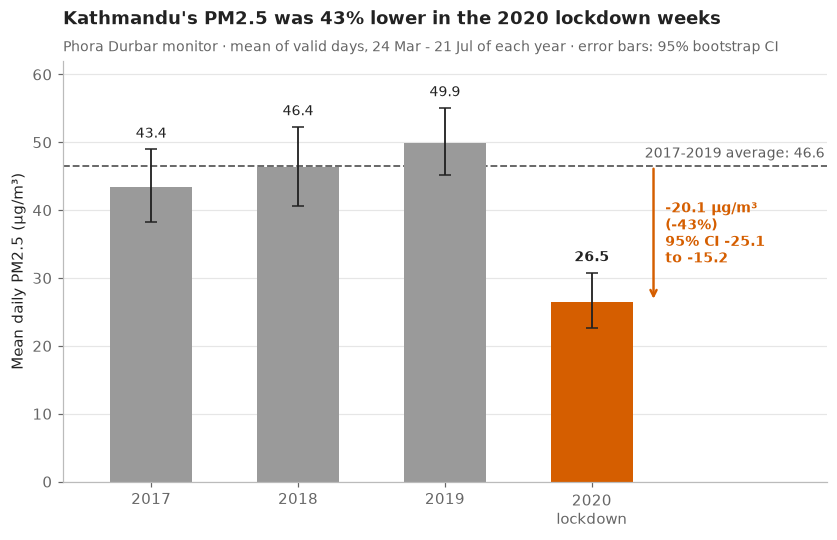

In [21]:
fig, ax = plt.subplots(figsize=(7.5, 4.8), layout="constrained")
x = np.arange(len(YEARS))
bar_colors = [ACCENT if y == LOCKDOWN_YEAR else CONTEXT for y in YEARS]
ax.bar(x, year_ci["mean"], width=0.56, color=bar_colors, zorder=2)
ax.errorbar(x, year_ci["mean"],
            yerr=[year_ci["mean"] - year_ci["ci_low"], year_ci["ci_high"] - year_ci["mean"]],
            fmt="none", ecolor=COLORS["ink"], elinewidth=1.2, capsize=4, zorder=3)
for xi, (y, row) in zip(x, year_ci.iterrows()):          # value labels above each error bar
    ax.text(xi, row["ci_high"] + 1.2, f"{row['mean']:.1f}", ha="center", va="bottom", fontsize=9,
            color=COLORS["ink"], fontweight="bold" if y == LOCKDOWN_YEAR else "normal")

ax.axhline(baseline, ls="--", lw=1.2, color=COLORS["context_dark"], zorder=1)
ax.text(3.36, baseline + 1.2, f"2017-2019 average: {baseline:.1f}", fontsize=9, color=COLORS["context_dark"])

# Bracket from the baseline down to the 2020 mean, with the main number
xb = 3.42
ax.annotate("", xy=(xb, lockdown_mean), xytext=(xb, baseline),
            arrowprops=dict(arrowstyle="->", color=ACCENT, lw=1.6))
ax.text(xb + 0.08, (baseline + lockdown_mean) / 2,
        f"{difference:+.1f} µg/m³\n({pct_change:+.0f}%)\n95% CI {ci_low:.1f}\nto {ci_high:.1f}",
        va="center", fontsize=9, color=ACCENT, fontweight="bold")

ax.set_xticks(x, [year_labels[y] for y in YEARS])
ax.set_xlim(-0.6, 4.6)
ax.set_ylim(0, 62)
ax.set_ylabel("Mean daily PM2.5 (µg/m³)")
titles(ax, f"Kathmandu's PM2.5 was {abs(pct_change):.0f}% lower in the 2020 lockdown weeks",
       "Phora Durbar monitor · mean of valid days, 24 Mar - 21 Jul of each year · error bars: 95% bootstrap CI")
save(fig, "01_main_finding")
plt.show()

**What it shows:** the three normal years sit close together (43-50 µg/m³) with overlapping intervals; 2020 sits far below all of them (26.5, CI 22.7-30.8). The gap to the 2017-2019 average is **−20.1 µg/m³ (−43%)**.

## Figure 2 · The data over time

**Why this chart:** before any summary, show the reader the actual daily values over the full four years. A line over time is the natural form; the thin line is every valid day, the thick line a 30-day average so the yearly cycle is visible through the noise. The shaded bands mark the comparison weeks (24 Mar - 21 Jul), orange in 2020. Gaps in the line are days without valid data.
*Alternatives considered:* only the 30-day average (hides the day-to-day spikes the reader should see); a calendar heatmap (good for patterns, harder to read values from).

saved figures/02_daily_pm25_2017_2021.png


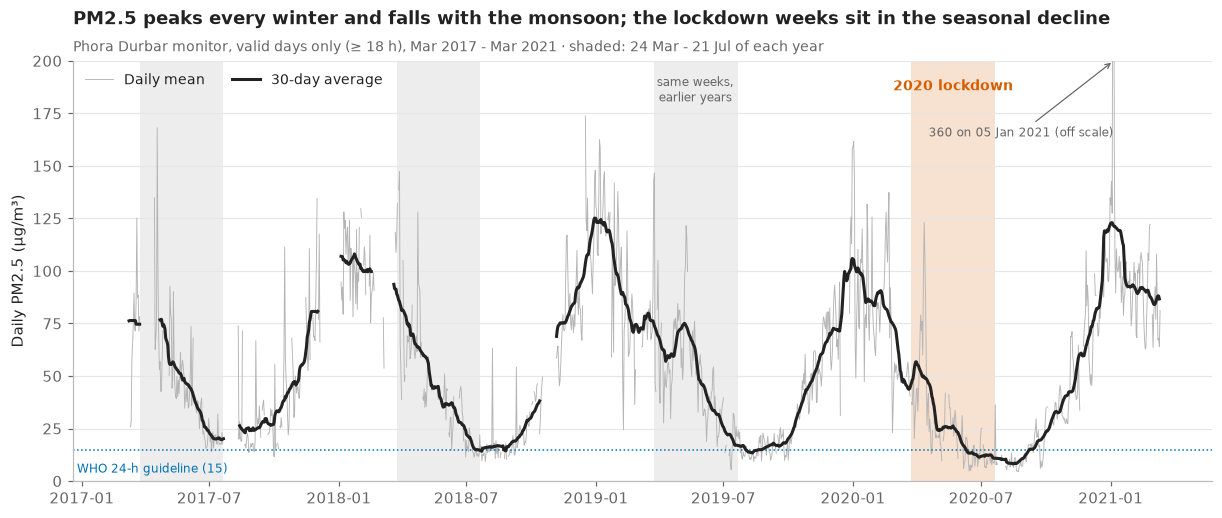

In [22]:
ts = (daily[daily["station"] == MAIN_STATION].set_index("date")["pm25_mean"]
      .where(daily[daily["station"] == MAIN_STATION].set_index("date")["valid_day"]))   # invalid days -> NaN
smooth30 = ts.rolling(30, center=True, min_periods=15).mean()

fig, ax = plt.subplots(figsize=(11, 4.6), layout="constrained")
for y in YEARS:
    start, end = pd.Timestamp(f"{y}-{WINDOW_START}"), pd.Timestamp(f"{y}-{WINDOW_END}")
    ax.axvspan(start, end, color=ACCENT if y == LOCKDOWN_YEAR else "#BBBBBB",
               alpha=0.18 if y == LOCKDOWN_YEAR else 0.25, lw=0, zorder=0)
ax.plot(ts.index, ts, lw=0.6, color="#B5B5B5", zorder=1, label="Daily mean")
ax.plot(smooth30.index, smooth30, lw=2, color=COLORS["ink"], zorder=2, label="30-day average")
ax.axhline(15, lw=1, ls=":", color=COLORS["second"], zorder=1)
ymax = 200                                                     # cap the axis so the seasons stay readable
peak_day = ts.idxmax()
ax.annotate(f"{ts.max():.0f} on {peak_day:%d %b %Y} (off scale)", xy=(peak_day, ymax), xytext=(peak_day, ymax * 0.82),
            ha="right", fontsize=8, color=COLORS["muted"], arrowprops=dict(arrowstyle="->", color=COLORS["muted"], lw=0.8))
ax.text(pd.Timestamp("2016-12-25"), 4, "WHO 24-h guideline (15)", color=COLORS["second"], fontsize=8, ha="left")
ax.text(pd.Timestamp("2020-05-22"), ymax * 0.93, "2020 lockdown", color=ACCENT, fontsize=9, ha="center", fontweight="bold")
ax.text(pd.Timestamp("2019-05-22"), ymax * 0.93, "same weeks,\nearlier years", color=COLORS["muted"], fontsize=8, ha="center", va="center")
ax.set_ylim(0, ymax)
ax.set_ylabel("Daily PM2.5 (µg/m³)")
ax.legend(loc="upper left", ncols=2, fontsize=9)
titles(ax, "PM2.5 peaks every winter and falls with the monsoon; the lockdown weeks sit in the seasonal decline",
       "Phora Durbar monitor, valid days only (≥ 18 h), Mar 2017 - Mar 2021 · shaded: 24 Mar - 21 Jul of each year")
save(fig, "02_daily_pm25_2017_2021")
plt.show()

**What it shows:** a strong yearly cycle, with winter peaks well above 100 µg/m³ (one real smog episode reached 360 µg/m³ on 5 January 2021) and monsoon lows near the WHO guideline. The comparison weeks always fall in the steep spring-to-monsoon decline, which is why the analysis compares the **same calendar weeks** across years. Visible gaps (e.g. spring 2017) are monitor outages.

## Figure 3 · The whole distribution, not only the means

**Why this chart:** means can hide a lot. A box per year (median and middle 50% of days) with every day drawn as a dot shows the full spread and lets the reader count. The orange dashed line marks the median 2020 day.
*Alternatives considered:* histograms per year (four histograms are hard to compare); a violin plot (smooth shape, but hides the individual days and their number).

Median 2020 day: 20.8 µg/m³; 82% of 2017-2019 window days were higher


saved figures/03_distribution_by_year.png


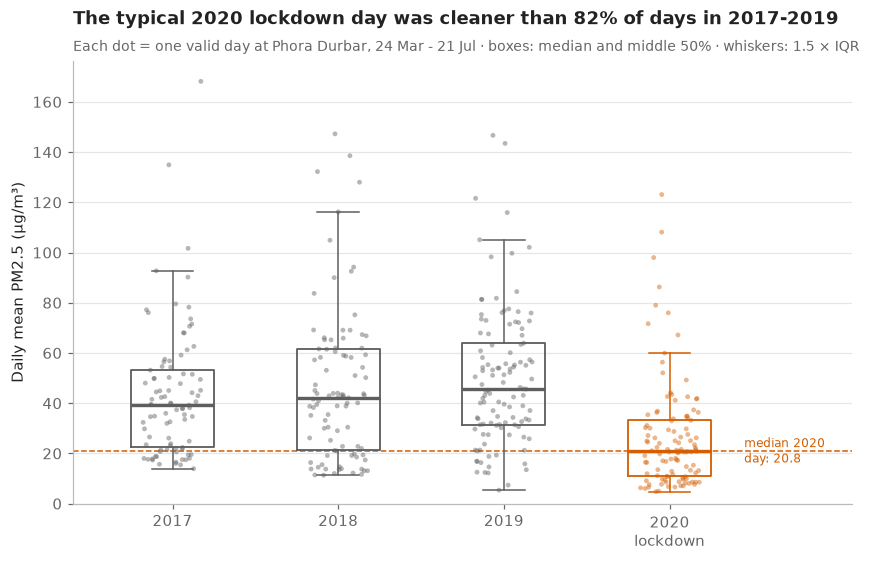

In [23]:
med_2020 = win.loc[win["year"] == LOCKDOWN_YEAR, "pm25_mean"].median()
base_days = win.loc[win["year"].isin(BASELINE_YEARS), "pm25_mean"]
share_above = (base_days > med_2020).mean()
print(f"Median 2020 day: {med_2020:.1f} µg/m³; {share_above:.0%} of 2017-2019 window days were higher")

fig, ax = plt.subplots(figsize=(8, 5), layout="constrained")
rng_jitter = np.random.default_rng(SEED)                      # jitter only spreads dots sideways
for i, y in enumerate(YEARS):
    v = win.loc[win["year"] == y, "pm25_mean"].to_numpy()
    color = ACCENT if y == LOCKDOWN_YEAR else COLORS["context_dark"]
    ax.scatter(i + rng_jitter.uniform(-0.18, 0.18, len(v)), v, s=10, alpha=0.45, color=color,
               edgecolor="none", zorder=2)
    ax.boxplot(v, positions=[i], widths=0.5, showfliers=False, zorder=3,
               medianprops=dict(color=color, lw=2.2), boxprops=dict(color=color, lw=1.2),
               whiskerprops=dict(color=color, lw=1), capprops=dict(color=color, lw=1))
ax.axhline(med_2020, ls="--", lw=1, color=ACCENT, zorder=1)
ax.text(3.45, med_2020, f"median 2020\nday: {med_2020:.1f}", color=ACCENT, fontsize=8, va="center")
ax.set_xticks(range(len(YEARS)), [year_labels[y] for y in YEARS])
ax.set_xlim(-0.6, 4.1)
ax.set_ylim(0, None)
ax.set_ylabel("Daily mean PM2.5 (µg/m³)")
titles(ax, f"The typical 2020 lockdown day was cleaner than {share_above:.0%} of days in 2017-2019",
       "Each dot = one valid day at Phora Durbar, 24 Mar - 21 Jul · boxes: median and middle 50% · whiskers: 1.5 × IQR")
save(fig, "03_distribution_by_year")
plt.show()

✅ **Check:** median 2020 day **20.8 µg/m³**; **82%** of 2017-2019 window days were higher.

**What it shows:** the whole 2020 distribution shifted down, not just a few days. The 2020 box sits below the other years' boxes, and only a handful of 2020 days (the mid-April smoke) reach the levels that were common before.

## Figure 4 · The breakdown by month

**Why this chart:** one estimate per month with its 95% CI, all on one horizontal scale with a zero line, makes "is it below zero every month?" a glance. Labels give the number and the percent.
*Alternatives considered:* grouped bars of 2020 vs baseline per month (shows levels, but the difference and its uncertainty have to be computed by eye); a table (precise, but no shape).

saved figures/04_difference_by_month.png


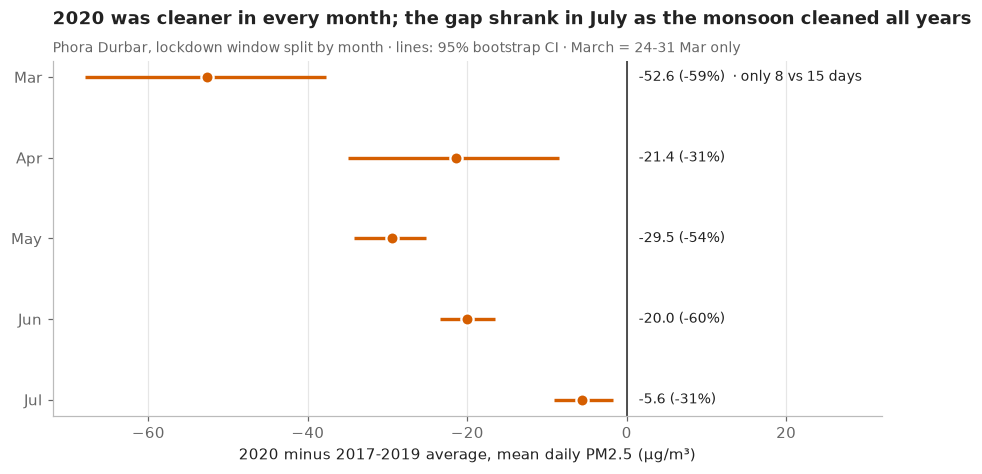

In [24]:
fig, ax = plt.subplots(figsize=(8, 4.2), layout="constrained")
ypos = np.arange(len(by_month))[::-1]                         # March at the top
ax.hlines(ypos, by_month["ci_low"], by_month["ci_high"], color=ACCENT, lw=2.2)
ax.plot(by_month["difference"], ypos, "o", ms=8, color=ACCENT, markeredgecolor="white", markeredgewidth=1.5)
ax.axvline(0, color=COLORS["ink"], lw=1)
for yp, (m, row) in zip(ypos, by_month.iterrows()):
    note = f"{row['difference']:+.1f} ({row['pct_change']:+.0f}%)"
    if m == "Mar":
        note += f"  · only {int(row['days_2020'])} vs {int(row['days_baseline'])} days"
    ax.text(1.5, yp, note, va="center", fontsize=9, color=COLORS["ink"])
ax.set_yticks(ypos, by_month.index)
ax.set_xlim(-72, 32)
ax.grid(axis="x", color=COLORS["grid"]); ax.grid(axis="y", visible=False)
ax.set_xlabel("2020 minus 2017-2019 average, mean daily PM2.5 (µg/m³)")
titles(ax, "2020 was cleaner in every month; the gap shrank in July as the monsoon cleaned all years",
       "Phora Durbar, lockdown window split by month · lines: 95% bootstrap CI · March = 24-31 Mar only")
save(fig, "04_difference_by_month")
plt.show()

**What it shows:** every month's interval lies left of zero. The drop is −20 to −30 µg/m³ from April to June and −5.6 in July, when monsoon rain keeps every year's air clean and the lockdown was being eased.

## Figure 5 · Data quality: where are the gaps?

**Why this chart:** a grid of year × month, coloured by the share of days that pass the 18-hour rule, shows *where* data is missing at a glance; the numbers in the cells give the exact share. One blue hue from light (few valid days) to dark (all valid) because this is a magnitude. The black outline marks the months of the comparison window.
*Alternatives considered:* a line of valid hours per day (notebook 01 has it; too detailed for the README); a bar per year (hides *which months* are missing, which is what matters here).

saved figures/05_data_coverage.png


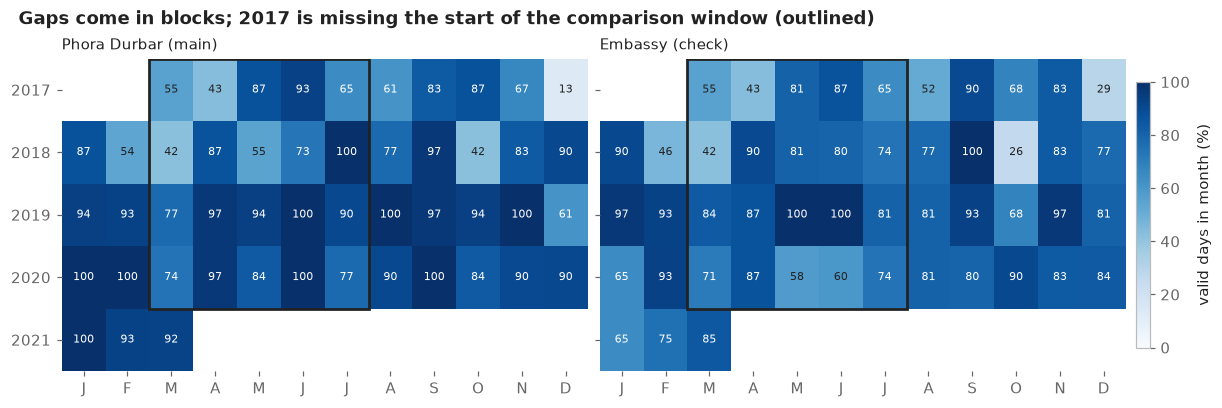

In [25]:
from matplotlib.patches import Rectangle

coverage_grid = (daily.assign(month=daily["date"].dt.month)
                 .groupby(["station", "year", "month"])["valid_day"].mean().mul(100))
station_names = {"phora_durbar": "Phora Durbar (main)", "embassy": "Embassy (check)"}
month_letters = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), layout="constrained", sharey=True)
for ax, st in zip(axes, ["phora_durbar", "embassy"]):
    grid = coverage_grid.loc[st].unstack("month").reindex(index=range(2017, 2022), columns=range(1, 13))
    im = ax.imshow(grid.to_numpy(), cmap="Blues", vmin=0, vmax=100, aspect="auto")
    for (r, c), val in np.ndenumerate(grid.to_numpy()):
        if not np.isnan(val):
            ax.text(c, r, f"{val:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if val > 60 else COLORS["ink"])
    ax.add_patch(Rectangle((1.5, -0.5), 5, 4, fill=False, lw=1.8, ec=COLORS["ink"]))   # Mar-Jul, 2017-2020
    ax.set_xticks(range(12), month_letters)
    ax.set_yticks(range(5), grid.index)
    ax.grid(False)
    ax.spines[:].set_visible(False)
    ax.set_title(station_names[st], fontsize=10, loc="left", fontweight="normal")
cbar = fig.colorbar(im, ax=axes, shrink=0.85, pad=0.01)
cbar.set_label("valid days in month (%)")
fig.suptitle("Gaps come in blocks; 2017 is missing the start of the comparison window (outlined)",
             x=0.01, ha="left", fontweight="bold", fontsize=12)
save(fig, "05_data_coverage")
plt.show()

**What it shows:** most months are 90-100% complete. The gaps come in blocks (monitor outages), and both stations share many of them. Inside the outlined window, **April 2017 is less than half complete**, the reason 2017's baseline is weakest; Embassy also has holes in May-June 2020. Empty cells are before the data starts (Jan-Feb 2017) or after it ends (Apr-Dec 2021).

## Figure 6 · Robustness checks in one picture

**Why this chart:** a "forest plot", one row per check with its estimate and 95% CI on a shared axis with a zero line, is the standard way to show that a result survives different choices. The main estimate is orange; the others grey.
*Alternatives considered:* the table from B1 (exact but slow to scan); bars per check (bars imply an amount from zero, while here the interval is what matters).

saved figures/06_robustness.png


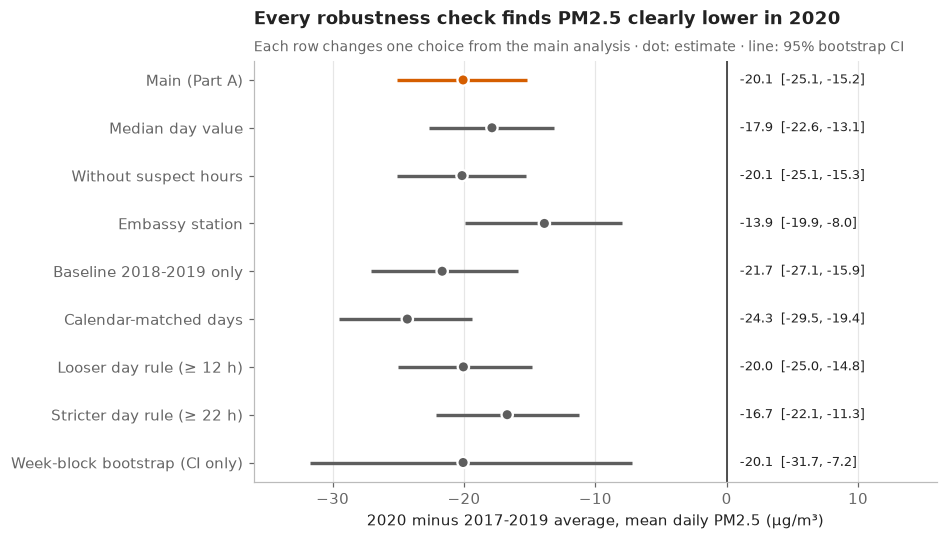

In [26]:
rob = robustness.iloc[::-1]                                   # main check at the top
fig, ax = plt.subplots(figsize=(8.5, 4.8), layout="constrained")
ypos = np.arange(len(rob))
is_main = rob.index.str.startswith("1 ")
colors = np.where(is_main, ACCENT, COLORS["context_dark"])
ax.hlines(ypos, rob["ci_low"], rob["ci_high"], color=colors, lw=2.2)
ax.scatter(rob["difference"], ypos, s=55, color=colors, edgecolor="white", linewidth=1.5, zorder=3)
ax.axvline(0, color=COLORS["ink"], lw=1)
for yp, (name, row) in zip(ypos, rob.iterrows()):
    ax.text(1.0, yp, f"{row['difference']:+.1f}  [{row['ci_low']:.1f}, {row['ci_high']:.1f}]",
            va="center", fontsize=8.5, color=COLORS["ink"])
ax.set_yticks(ypos, [n.split(" ", 1)[1] for n in rob.index])
ax.set_xlim(-36, 16)
ax.grid(axis="x", color=COLORS["grid"]); ax.grid(axis="y", visible=False)
ax.set_xlabel("2020 minus 2017-2019 average, mean daily PM2.5 (µg/m³)")
titles(ax, "Every robustness check finds PM2.5 clearly lower in 2020",
       "Each row changes one choice from the main analysis · dot: estimate · line: 95% bootstrap CI")
save(fig, "06_robustness")
plt.show()

**What it shows:** all nine intervals lie left of zero. Most estimates cluster around −17 to −22 µg/m³; the Embassy station is the smallest drop and calendar-matched days the largest. The week-block row has the widest interval: the honest range for the size of the drop.

## Figure 7 · Day by day through the lockdown window

**Why this chart:** lines for the four years on one "day of the window" axis show *when* 2020 differed, which the means can't. A 7-day average smooths daily noise; missing days leave gaps instead of fake straight lines. The shaded band marks the mid-April wildfire episode.
*Alternatives considered:* four small panels (each year alone, but the comparison needs one shared axis); raw daily values (too noisy to compare four years).

saved figures/07_lockdown_window_by_year.png


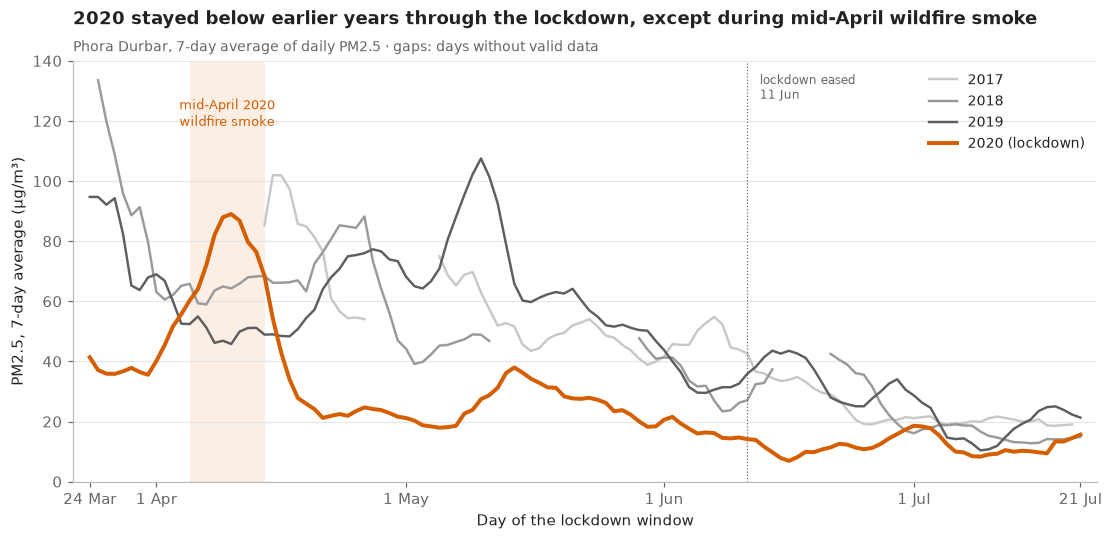

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.8), layout="constrained")
for y in YEARS:
    s = win[win["year"] == y].set_index("day")["pm25_mean"].reindex(range(120))
    smooth = s.rolling(7, center=True, min_periods=4).mean()
    ax.plot(smooth.index, smooth, color=YEAR_COLORS[y], lw=2.6 if y == LOCKDOWN_YEAR else 1.6,
            label=str(y) + (" (lockdown)" if y == LOCKDOWN_YEAR else ""), zorder=3 if y == LOCKDOWN_YEAR else 2)

fire_start, fire_end = 12, 21                                  # 5-14 April = days 12-21 of the window
ax.axvspan(fire_start, fire_end, color=ACCENT, alpha=0.10, lw=0, zorder=0)
ax.text((fire_start + fire_end) / 2, 128, "mid-April 2020\nwildfire smoke", ha="center", va="top",
        fontsize=8.5, color=ACCENT)
ax.text(80.5, 136, "lockdown eased\n11 Jun", ha="left", va="top", fontsize=8, color=COLORS["muted"])
ax.axvline(79, color=COLORS["muted"], lw=0.8, ls=":")          # 11 June = day 79

ticks = [0, 8, 38, 69, 99, 119]
ax.set_xticks(ticks, ["24 Mar", "1 Apr", "1 May", "1 Jun", "1 Jul", "21 Jul"])
ax.set_xlim(-2, 121)
ax.set_ylim(0, 140)
ax.set_ylabel("PM2.5, 7-day average (µg/m³)")
ax.set_xlabel("Day of the lockdown window")
ax.legend(loc="upper right", fontsize=9)
titles(ax, "2020 stayed below earlier years through the lockdown, except during mid-April wildfire smoke",
       "Phora Durbar, 7-day average of daily PM2.5 · gaps: days without valid data")
save(fig, "07_lockdown_window_by_year")
plt.show()

**What it shows:** the orange 2020 line runs below the grey lines for almost the whole window. The one exception is the mid-April spike, when wildfire smoke from surrounding districts reached the valley even with traffic stopped (Nepali Times, 1 Sep 2020). By July all four years converge as the monsoon cleans the air.

**Source for the wildfire episode:** *"Nepal sees drop in wildfires during lockdown"*, Nepali Times, 1 September 2020: "a sharp deterioration in air quality mid April this year in Kathmandu Valley despite vehicles being off the roads"; NASA satellite data showed more carbon monoxide and nitrogen dioxide on 9-14 April 2020 than on the same days of 2019.

---
# Conclusion

**Question:** during Nepal's 2020 COVID lockdown (24 March - 21 July 2020), was Kathmandu's daily PM2.5 lower than in the same calendar weeks of 2017-2019, and by how much?

**Answer:** yes. At the Phora Durbar monitor, mean daily PM2.5 in the lockdown weeks was **26.5 µg/m³**, against **46.6 µg/m³** in the same weeks of 2017-2019: **20.1 µg/m³ lower (95% CI 15.2 to 25.1), a 43% drop**. The drop holds in every month and in all nine robustness checks (estimates −13.9 to −24.3 µg/m³, every CI below zero). Because consecutive days are strongly linked, the size is less certain than the main CI suggests (week-block CI 7.2 to 31.7 lower), but the direction is not in doubt. In plain words: **during the lockdown, central Kathmandu's air carried roughly 40% less fine-particle pollution than in a normal year at the same time**. Even so it averaged above the WHO 24-hour guideline (15 µg/m³), and wildfire smoke still produced bad days in mid-April.

**What this can't show:** that the lockdown *caused* all of the drop. Weather, rain and wildfires also differ between years, and this is one monitor in one part of the valley. The full limitations are in the README.

In [28]:
print(f"Final answer: 2020 lockdown weeks minus 2017-2019 same weeks = {difference:+.1f} µg/m³ "
      f"(95% CI {ci_low:+.1f} to {ci_high:+.1f}), {pct_change:+.1f}%")

Final answer: 2020 lockdown weeks minus 2017-2019 same weeks = -20.1 µg/m³ (95% CI -25.1 to -15.2), -43.1%


✅ **Check:** `Final answer: 2020 lockdown weeks minus 2017-2019 same weeks = -20.1 µg/m³ (95% CI -25.1 to -15.2), -43.1%`